VISUALS

0- Data preparation and library import

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# 1. Connect to your database
engine = create_engine('sqlite:///uni_data.db')

# 2. Use a SQL JOIN to pull all data into one DataFrame for plotting
query = """
SELECT u.*, s.region, s.median_household_income, s.state_name
FROM universities u
JOIN state_info s ON u.state = s.state_code
"""
df_all = pd.read_sql(query, con=engine)

# Set the visual style
sns.set_theme(style="whitegrid")


📈 Visual for Q1: Regional Research Impact

Question: Which U.S. Region has the highest average Research Impact Score?

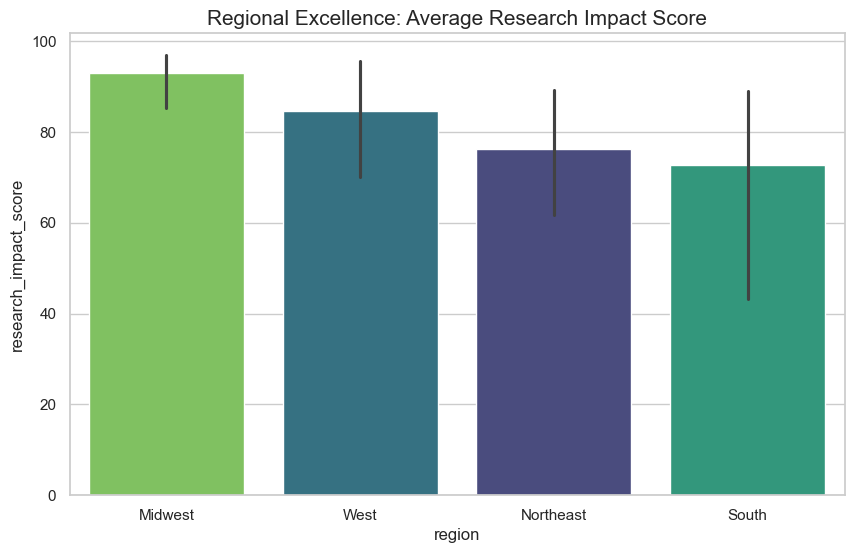

In [8]:
# --- VISUAL 1: Regional Research Impact (For SQL Q1) ---
plt.figure(figsize=(10, 6))
order = df_all.groupby('region')['research_impact_score'].mean().sort_values(ascending=False).index
sns.barplot(data=df_all, x='region', y='research_impact_score', hue='region', 
            palette='viridis', order=order, legend=False)
plt.title('Regional Excellence: Average Research Impact Score', fontsize=15)
plt.show()

📈 Visual for Q5: State Wealth vs Rank

Question: Does being an "Elite" school (Rank 1-5) correlate with being in a high-income state (>$80k)?

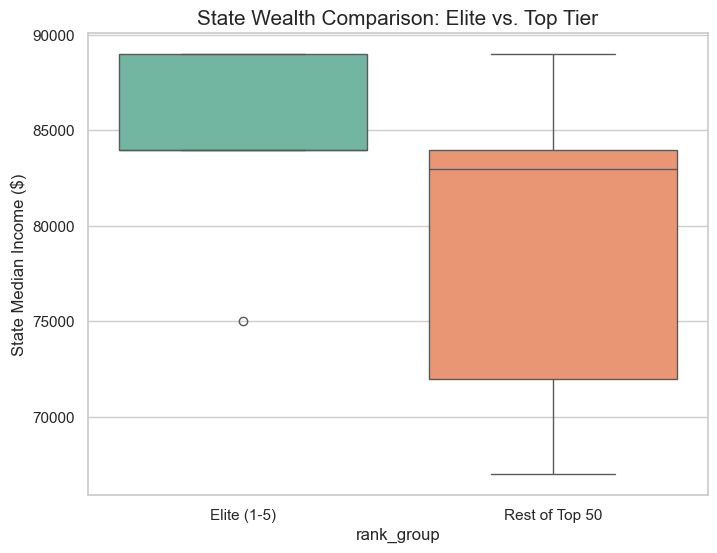

In [9]:
# --- VISUAL for Q5: Ranking vs. Income Tiers (CASE Statement + JOIN)
df_all['rank_group'] = df_all['national_rank'].apply(lambda x: 'Elite (1-5)' if x <= 5 else 'Rest of Top 50')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_all, x='rank_group', y='median_household_income', hue='rank_group', 
            palette='Set2', legend=False)
plt.title('State Wealth Comparison: Elite vs. Top Tier', fontsize=15)
plt.ylabel('State Median Income ($)')
plt.show()

📈 Visual for Q8: Employment Rate Distribution

Question: List Public universities that have a higher Employment Rate than the average of all Private universities.

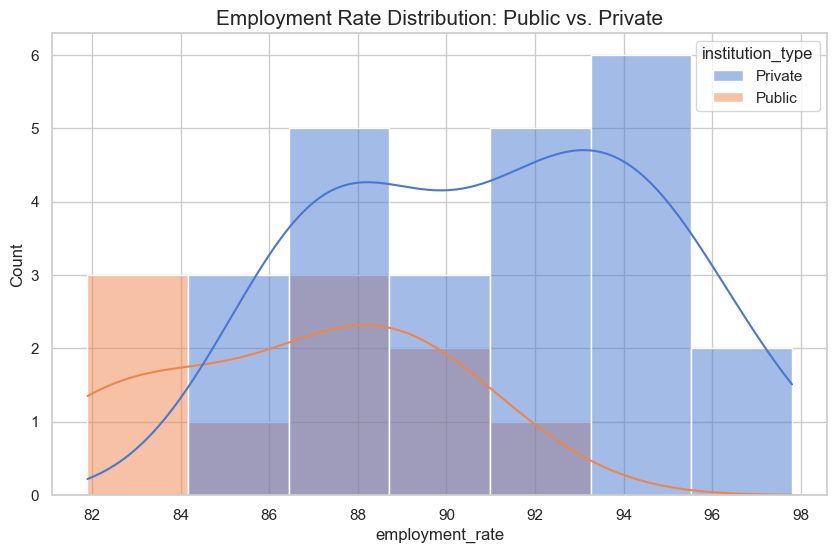

In [10]:
# --- VISUAL 4: Employment Rate Distribution (For SQL Q8) ---
plt.figure(figsize=(10, 6))
sns.histplot(data=df_all, x='employment_rate', hue='institution_type', kde=True, palette='muted')
plt.title('Employment Rate Distribution: Public vs. Private', fontsize=15)
plt.show()

📈 Visual for Q9: Regional Diversity Count (JOIN + DISTINCT)

Question: How many different states in each region have at least one university in the Top 50?

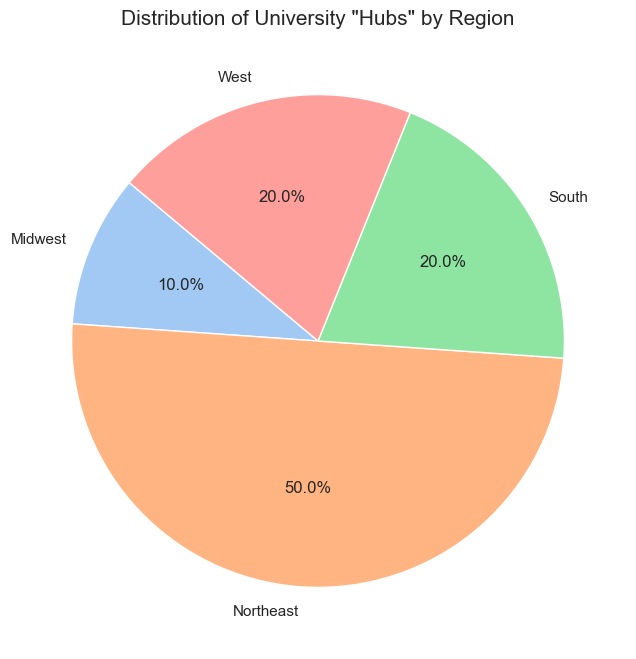

In [11]:
# --- VISUAL 3: University Hubs by Region (For SQL Q9) ---
active_states = df_all.groupby('region')['state'].nunique()
plt.figure(figsize=(8, 8))
plt.pie(active_states, labels=active_states.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of University "Hubs" by Region', fontsize=15)
plt.show()